# **Project Name**    -   Flipkart Customer Service Satisfaction Analysis



##### **Project Type**    - Exploratory Data Analysis (EDA) and Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Mohammad Sajjaduddin


# **Project Summary -**

## Project Summary

Customer satisfaction plays a critical role in the success of any e-commerce platform. High customer satisfaction improves customer retention, strengthens brand loyalty, and increases the likelihood of repeat purchases. This project focuses on analyzing customer support interactions from Flipkart to understand the factors that influence Customer Satisfaction (CSAT) scores and identify opportunities to improve service quality.

The dataset contains information about customer support requests, including communication channels, issue categories, response timestamps, customer remarks, item prices, employee details, tenure information, and customer satisfaction scores. These variables provide valuable insights into how efficiently customer issues are handled and how different operational factors affect customer experience.

The project begins with data exploration to understand the dataset's structure, identify missing values, detect duplicate records, and examine data types. Data preprocessing techniques are then applied to clean the dataset by handling missing values, converting date columns into datetime format, removing irrelevant features with excessive missing data, and creating new features such as response time. These preprocessing steps improve the quality of the data and prepare it for analysis.

Exploratory Data Analysis (EDA) is performed using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn. Various univariate, bivariate, and multivariate visualizations are created to study the distribution of customer satisfaction scores, response times, support channels, issue categories, agent shifts, tenure buckets, and other important business variables. Each visualization is interpreted to identify patterns, trends, and relationships that influence customer satisfaction.

After completing the exploratory analysis, a machine learning classification model is developed to predict customer satisfaction scores. Relevant features such as response time, item price, support channel, issue category, tenure bucket, and agent shift are selected for model training. Categorical variables are converted into numerical form using one-hot encoding, and the dataset is divided into training and testing sets. A Random Forest Classifier is trained and evaluated using accuracy, precision, recall, and F1-score.

The insights generated from this project help identify key factors affecting customer satisfaction and provide recommendations for improving customer support services. The results can assist Flipkart in reducing response times, improving service quality across different support channels, enhancing agent performance, and increasing overall customer satisfaction. This project demonstrates practical applications of data preprocessing, exploratory data analysis, visualization, feature engineering, and machine learning in solving real-world business problems.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Customer satisfaction is one of the most important performance indicators for any e-commerce platform. Every day, thousands of customers contact Flipkart's customer support team through various communication channels regarding product issues, order delays, payment problems, returns, and other service-related concerns.

Although Flipkart receives customer feedback through Customer Satisfaction (CSAT) scores, it is difficult to manually identify the factors that influence customer satisfaction across such a large volume of interactions. Delayed responses, inefficient issue handling, differences in support channels, and operational inefficiencies may negatively affect the customer experience.

The challenge is to analyze historical customer support data to understand which factors have the greatest impact on customer satisfaction and develop a predictive model that can estimate CSAT scores based on customer interaction details. The insights obtained from this analysis can help Flipkart improve service quality, reduce response times, optimize customer support operations, and increase overall customer satisfaction.

#### **Define Your Business Objective?**

The primary objective of this project is to analyze Flipkart customer support data and identify the key factors that influence customer satisfaction (CSAT) scores. By performing data preprocessing, exploratory data analysis, and machine learning, the project aims to discover meaningful business insights and predict customer satisfaction based on customer support interactions.

The specific business objectives are:

- Understand the distribution of customer satisfaction scores.
- Analyze customer support channels and their impact on CSAT.
- Examine the relationship between response time and customer satisfaction.
- Identify important issue categories affecting customer experience.
- Study the influence of agent shift and employee tenure on service quality.
- Build a machine learning model capable of predicting customer satisfaction.
- Provide business recommendations to improve customer support efficiency and enhance the overall customer experience.

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Display plots inside notebook
%matplotlib inline

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Dataset Loading

In [27]:
# Loading the dataset into a Pandas DataFrame
df = pd.read_csv("Customer_support_data.csv")

# Display first five rows
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset First View

In [28]:
# Display the last 5 rows of the dataset
df.tail()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30/08/2023 23:20,31/08/2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31/08/2023 08:15,31/08/2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31/08/2023 18:57,31/08/2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85905,707528ee-6873-4192-bfa9-a491f1c08ab5,Inbound,Feedback,UnProfessional Behaviour,NaN,a031ec28-0c5e-450e-95b2-592342c40bc4,NaN,31/08/2023 19:59,31/08/2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4
85906,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,NaN,3230db30-f8da-4c44-8636-ec76d1d3d4f3,NaN,31/08/2023 23:36,31/08/2023 23:37,31-Aug-23,NaN,NaN,NaN,NaN,Elizabeth Guerra,Nathan Patel,Jennifer Nguyen,On Job Training,Evening,5


### Dataset Rows & Columns count

In [29]:
# Display the number of rows and columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 85907
Number of Columns: 20


### Dataset Information

In [30]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

#### Duplicate Values

In [31]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


#### Missing Values/Null Values

In [32]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()

# Display missing values
missing_values

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

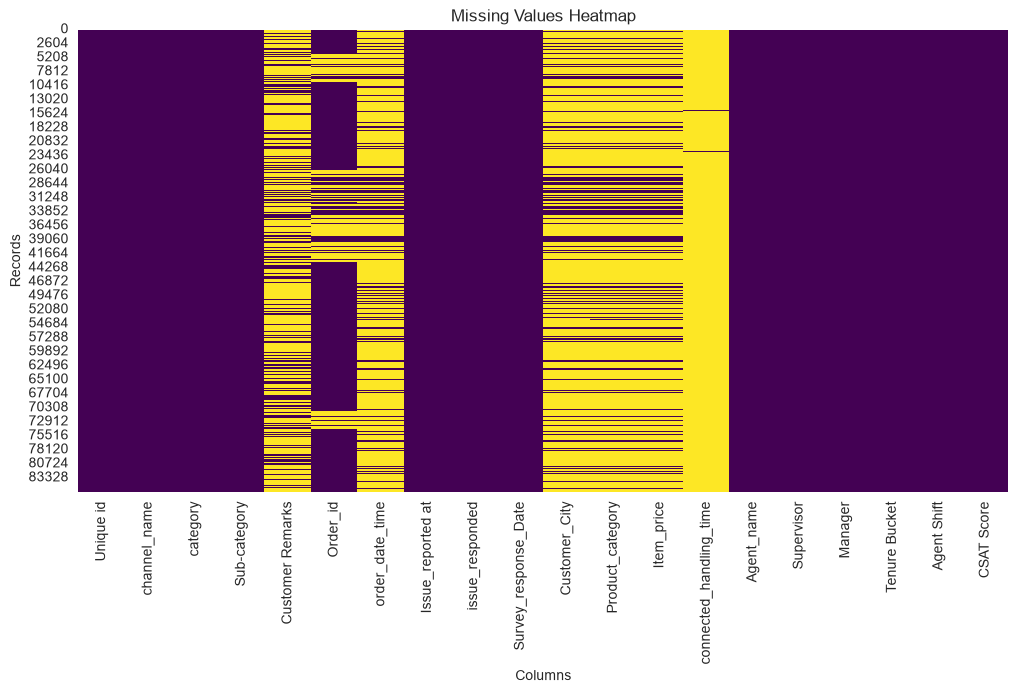

In [33]:
# Visualizing the missing values
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Records")

plt.show()

### What did you know about your dataset?

The dataset contains **85,907 customer support records** with **20 features** related to customer interactions, support channels, issue categories, response timestamps, employee information, and Customer Satisfaction (CSAT) scores.

The dataset consists of both categorical and numerical variables. The target variable is **CSAT Score**, which ranges from 1 to 5 and represents the customer's satisfaction level.

Initial exploration revealed that several columns contain a significant number of missing values, particularly **Customer_City**, **Product_category**, **Item_price**, **connected_handling_time**, and **order_date_time**. These missing values will be handled during the data preprocessing stage.

No duplicate records were found in the dataset (if your duplicate count was 0). The dataset is sufficiently large for exploratory data analysis and machine learning, making it suitable for identifying customer satisfaction trends and predicting CSAT scores.

## ***2. Understanding Your Variables***

In [34]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='str')

In [35]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

The dataset contains customer support details such as support channel, issue category, customer remarks, order details, response dates, agent information, tenure, shift, item price, and the target variable **CSAT Score**, which represents customer satisfaction.

### Check Unique Values for each variable.

In [36]:
# Check Unique Values for each variable.
df.nunique()

Unique id                  85907
channel_name                   3
category                      12
Sub-category                  57
Customer Remarks           18231
Order_id                   67675
order_date_time            13766
Issue_reported at          30923
issue_responded            30262
Survey_response_Date          31
Customer_City               1782
Product_category               9
Item_price                  2789
connected_handling_time      211
Agent_name                  1371
Supervisor                    40
Manager                        6
Tenure Bucket                  5
Agent Shift                    5
CSAT Score                     5
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [37]:
# Write your code to make your dataset analysis ready.
# Convert date columns to datetime format
date_columns = [
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

In [38]:
# Fill missing values
df["Customer Remarks"] = df["Customer Remarks"].fillna("No Remarks")
df["Item_price"] = df["Item_price"].fillna(df["Item_price"].median())

In [39]:
# Drop unnecessary columns
df.drop(
    columns=["Customer_City", "Product_category", "connected_handling_time"],
    inplace=True
)

In [40]:
# Create response time feature
df["response_time"] = (
    df["issue_responded"] - df["Issue_reported at"]
).dt.total_seconds()

df["response_time"] = df["response_time"].fillna(
    df["response_time"].median()
)

In [41]:
# Check dataset information
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unique id             85907 non-null  str           
 1   channel_name          85907 non-null  str           
 2   category              85907 non-null  str           
 3   Sub-category          85907 non-null  str           
 4   Customer Remarks      85907 non-null  str           
 5   Order_id              67675 non-null  str           
 6   order_date_time       17214 non-null  datetime64[us]
 7   Issue_reported at     85907 non-null  datetime64[us]
 8   issue_responded       85907 non-null  datetime64[us]
 9   Survey_response_Date  85907 non-null  datetime64[us]
 10  Item_price            85907 non-null  float64       
 11  Agent_name            85907 non-null  str           
 12  Supervisor            85907 non-null  str           
 13  Manager               85907

Unique id                   0
channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Order_id                18232
order_date_time         68693
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
response_time               0
dtype: int64

In [42]:
# Final dataset shape
print("Dataset Shape:", df.shape)

# Check remaining missing values
df.isnull().sum()

Dataset Shape: (85907, 18)


Unique id                   0
channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Order_id                18232
order_date_time         68693
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
response_time               0
dtype: int64

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Distribution of CSAT Score

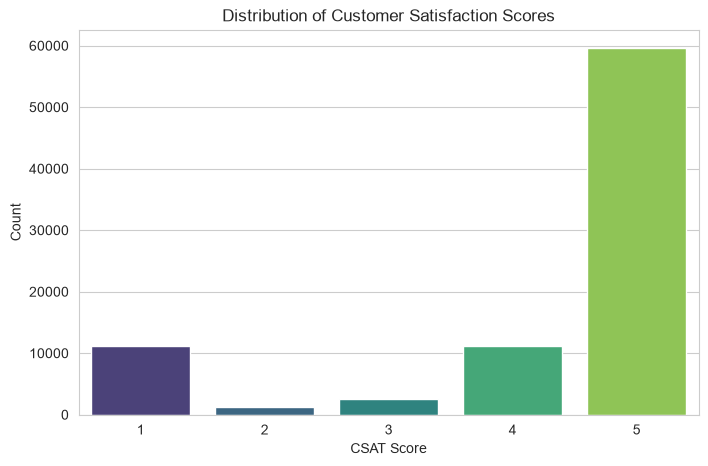

In [43]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))

sns.countplot(
    x="CSAT Score",
    data=df,
    palette="viridis"
)

plt.title("Distribution of Customer Satisfaction Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot is used to visualize the frequency of each CSAT score. It helps understand how customer satisfaction ratings are distributed and identifies the most common satisfaction level.

##### 2. What is/are the insight(s) found from the chart?

- CSAT Score **5** has the highest number of responses.
- Scores **2** and **3** have the lowest number of responses.
- A noticeable number of customers gave ratings of **1** and **4**.
- Overall, the distribution is skewed towards higher satisfaction scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart indicates that most customers are satisfied with Flipkart's customer support service. However, customers who gave low ratings (1 and 2) should be analyzed further to identify the reasons for dissatisfaction. Addressing these issues can improve customer experience, increase customer retention, and strengthen brand loyalty.

#### Chart - 2 : Response Time vs CSAT Score


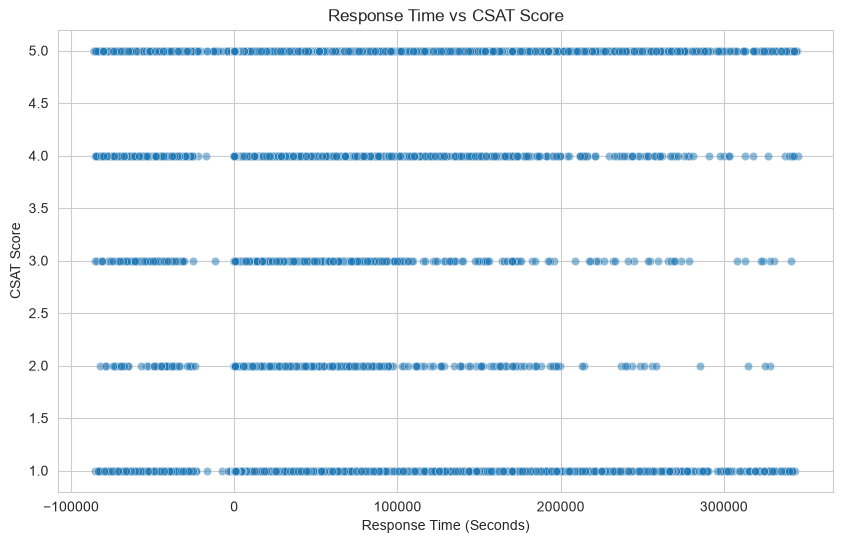

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="response_time",
    y="CSAT Score",
    data=df,
    alpha=0.5
)

plt.title("Response Time vs CSAT Score")
plt.xlabel("Response Time (Seconds)")
plt.ylabel("CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to examine the relationship between two numerical variables: response time and CSAT score. It helps identify trends, patterns, and any possible correlation between customer response time and satisfaction.

##### 2. What is/are the insight(s) found from the chart?

- The scatter plot does not show a strong relationship between response time and CSAT score.
- All CSAT scores (1 to 5) are observed across both short and long response times.
- High response times do not always result in low customer satisfaction.
- This suggests that factors other than response time, such as issue resolution quality or customer support experience, may also influence CSAT scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The analysis suggests that improving customer satisfaction requires more than simply reducing response time. Flipkart should also focus on service quality, effective issue resolution, and customer communication.

A negative insight is that some customers still give low CSAT scores even when response times are short. This indicates that faster responses alone do not guarantee customer satisfaction, and other service-related factors should be investigated.

#### Chart - 3  Response Time by Agent Shift

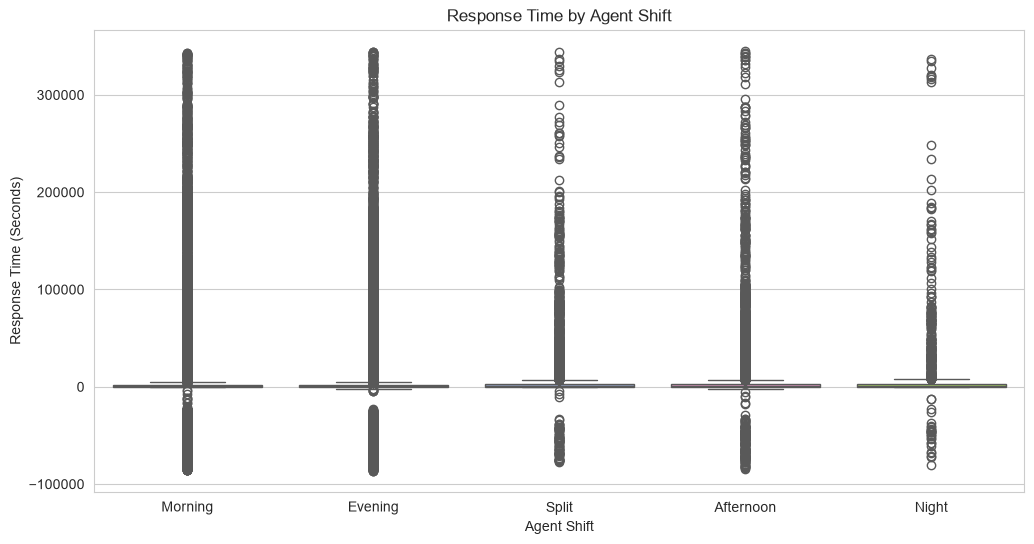

In [44]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Agent Shift",
    y="response_time",
    data=df,
    palette="Set2"
)

plt.title("Response Time by Agent Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Response Time (Seconds)")

plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to compare the distribution of response times across different agent shifts and identify outliers.

##### 2. What is/are the insight(s) found from the chart?

- Response times are similar across all agent shifts.
- All shifts contain many outliers, indicating some cases take much longer than others.
- No single shift performs significantly better or worse.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The company can investigate the outlier cases to reduce delays and improve customer service. Long response times may reduce customer satisfaction if they are not addressed.

#### Chart - 4  Distribution of Item Price

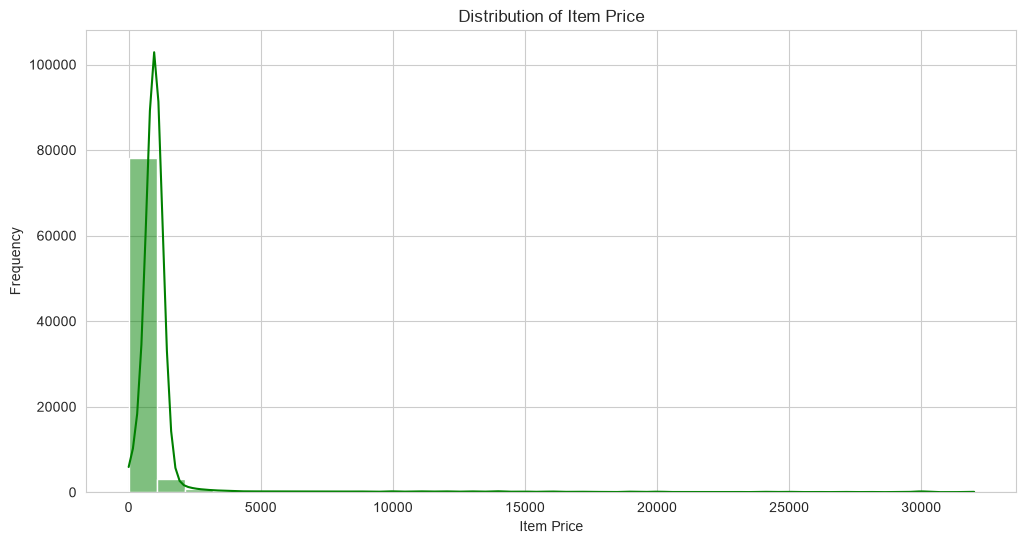

In [47]:
plt.figure(figsize=(12,6))

sns.histplot(
    df[df["Item_price"] <= df["Item_price"].quantile(0.99)]["Item_price"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of Item Price")
plt.xlabel("Item Price")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is used to visualize the distribution of item prices and identify the spread, concentration, and skewness of the data.

##### 2. What is/are the insight(s) found from the chart?

- Most products are low-priced.
- The distribution is highly right-skewed.
- Only a small number of products have very high prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The analysis helps Flipkart understand customer purchasing patterns and optimize pricing strategies. The presence of a few very high-priced products indicates a niche market, while most sales are likely concentrated in lower-priced items.

#### Chart - 5  Response Time vs Item Price

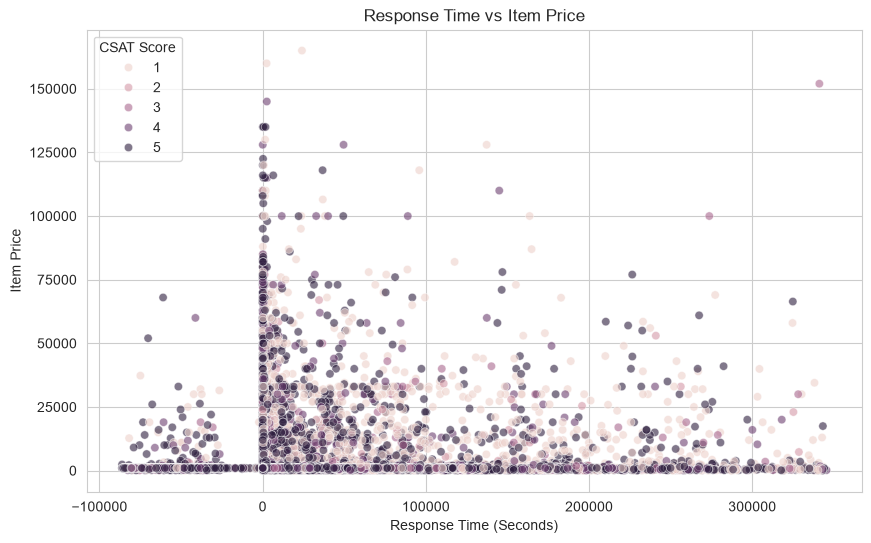

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="response_time",
    y="Item_price",
    hue="CSAT Score",
    data=df,
    alpha=0.6
)

plt.title("Response Time vs Item Price")
plt.xlabel("Response Time (Seconds)")
plt.ylabel("Item Price")

plt.legend(title="CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to examine the relationship between response time and item price while showing CSAT scores using different colors.

##### 2. What is/are the insight(s) found from the chart?

- There is no clear relationship between response time and item price.
- Most products are low-priced regardless of response time.
- All CSAT scores are distributed across different response times and item prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart suggests that item price alone does not influence response time or customer satisfaction. Flipkart should focus on improving service quality across all price ranges rather than prioritizing only high-priced products.

#### Chart - 6  Occurrence of Each Support Channel

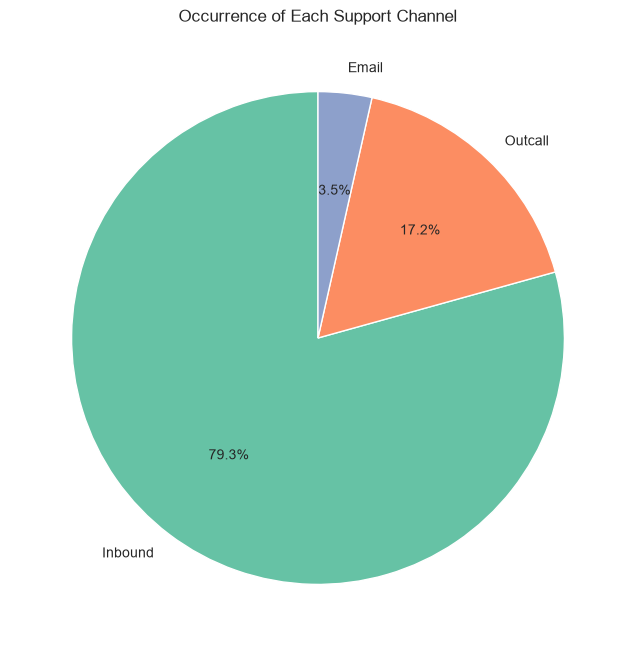

In [50]:
plt.figure(figsize=(8,8))

channel_counts = df["channel_name"].value_counts()

plt.pie(
    channel_counts,
    labels=channel_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2"),
    startangle=90
)

plt.title("Occurrence of Each Support Channel")

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is used to show the proportion of customer support cases handled through each support channel.

##### 2. What is/are the insight(s) found from the chart?

- Inbound handles the majority of support cases (79.3%).
- Outcall accounts for 17.2% of the cases.
- Email is the least used support channel with only 3.5% of cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Since most customer interactions occur through the Inbound channel, Flipkart should allocate more resources to improve its efficiency. The low usage of the Email channel may indicate lower customer preference or limited adoption, which should be evaluated for possible improvements.

#### Chart - 7  Average CSAT Score by Agent Shift

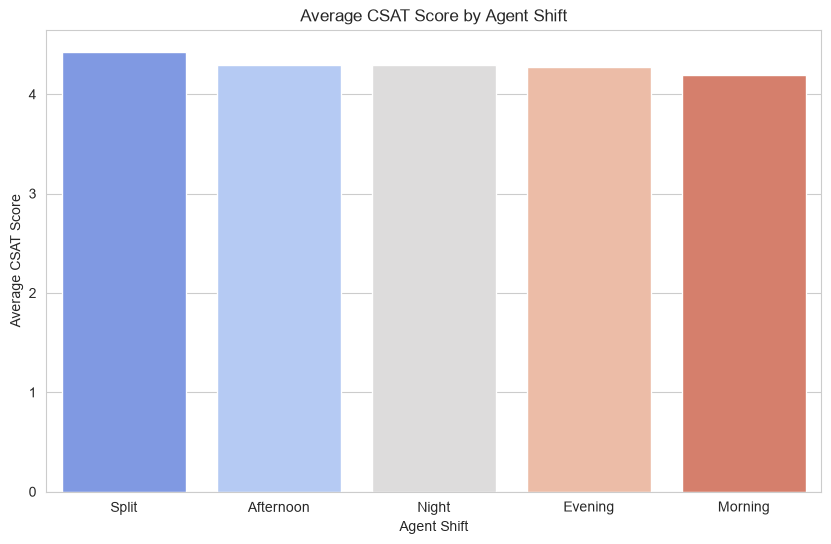

In [ ]:

agent_shift_csat = (
    df.groupby("Agent Shift")["CSAT Score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=agent_shift_csat.index,
    y=agent_shift_csat.values,
    palette="coolwarm"
)

plt.title("Average CSAT Score by Agent Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Average CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare the average CSAT score across different agent shifts.

##### 2. What is/are the insight(s) found from the chart?

- Split shift has the highest average CSAT score.
- Morning shift has the lowest average CSAT score.
- The average CSAT scores are very similar across all shifts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify shifts with relatively lower customer satisfaction so that training and operational improvements can be targeted. Although the differences are small, improving the Morning shift could further enhance overall customer satisfaction.

#### Chart - 8   CSAT Score by Product Category

In [57]:
df_city = pd.read_csv("Customer_support_data.csv")

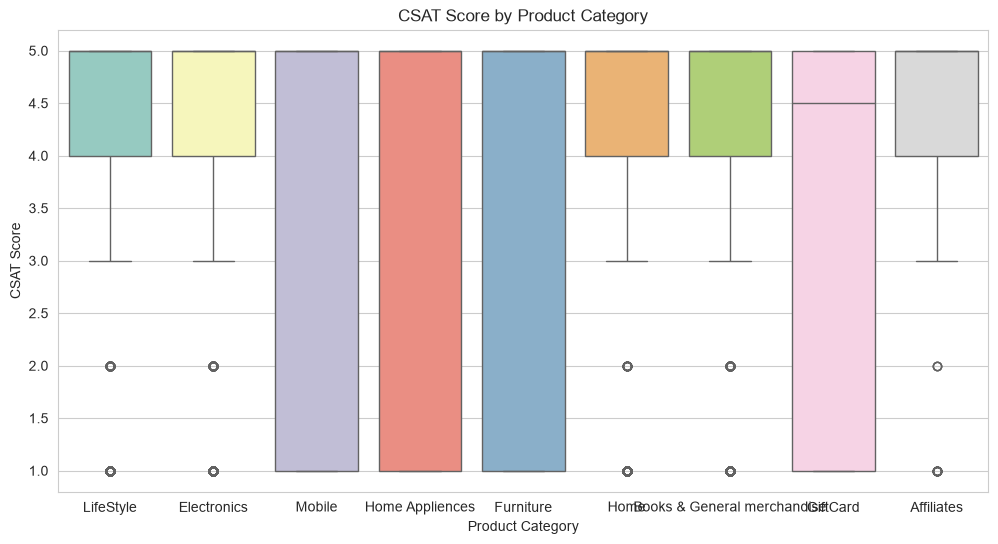

In [59]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Product_category",
    y="CSAT Score",
    data=df_city,      # or df_original
    palette="Set3"
)

plt.title("CSAT Score by Product Category")
plt.xlabel("Product Category")
plt.ylabel("CSAT Score")


plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to compare the distribution of CSAT scores across different product categories and identify variations and outliers.

##### 2. What is/are the insight(s) found from the chart?

- Most product categories have high CSAT scores between 4 and 5.
- Categories such as Mobile, Furniture, and Home Appliances show a wider spread in customer satisfaction.
- A few low ratings (1 and 2) are present across several product categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Product categories with greater variation in CSAT scores should be analyzed to identify service issues and improve customer experience. Low CSAT ratings in some categories indicate areas where support quality or product-related issues may need attention.

#### Chart - 9   CSAT Score Distribution by Support Channel

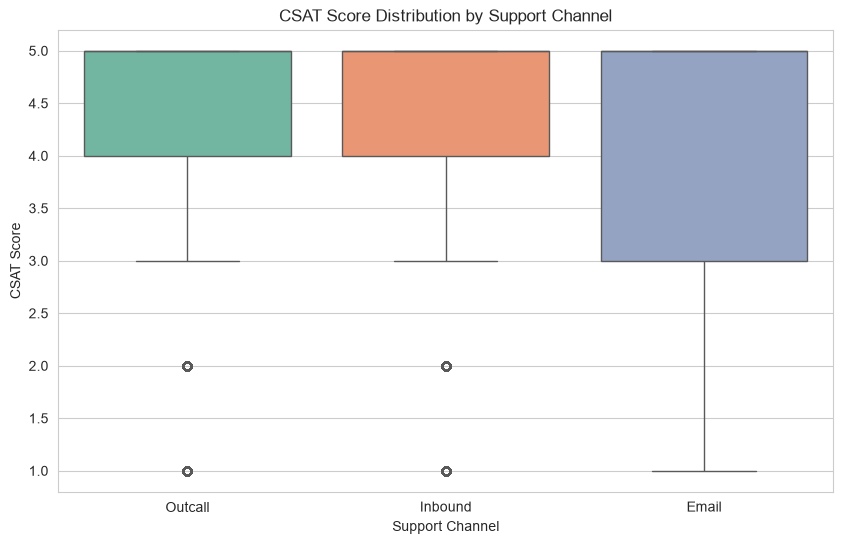

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="channel_name",
    y="CSAT Score",
    data=df,
    palette="Set2"
)

plt.title("CSAT Score Distribution by Support Channel")
plt.xlabel("Support Channel")
plt.ylabel("CSAT Score")

plt.show()

##### 1. Why did you pick the specific chart?

AnswerA box plot is used to compare the distribution and spread of CSAT scores across different support channels. Here.

##### 2. What is/are the insight(s) found from the chart?

- Inbound and Outcall have similar CSAT score distributions.
- Email shows a wider spread of CSAT scores, indicating greater variation in customer satisfaction.
- Most customer ratings across all channels are between 4 and 5.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify which support channels have more consistent customer satisfaction. The wider variation in the Email channel suggests it may require improvements to provide a more consistent customer experience.

#### Chart - 10   Agent Tenure vs Average CSAT Score

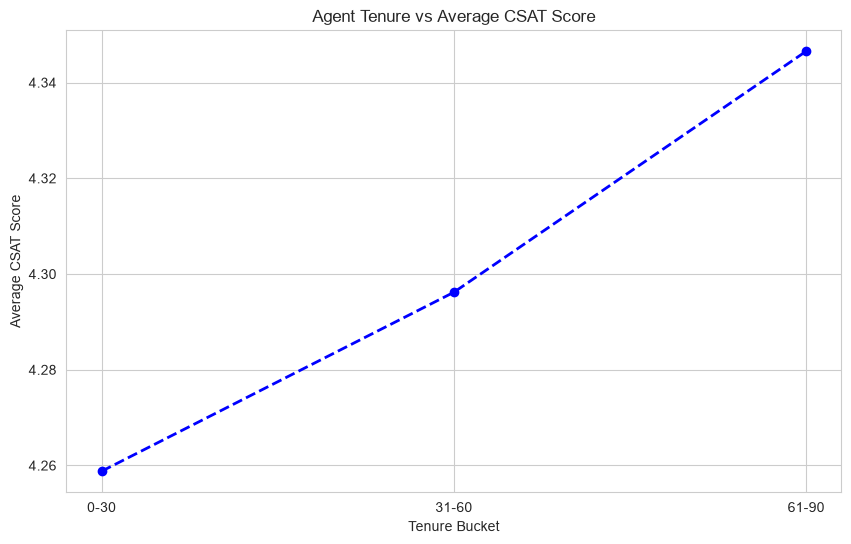

In [ ]:


tenure_csat = (
    df.groupby("Tenure Bucket")["CSAT Score"]
      .mean()
      .reindex([
          "0-30",
          "31-60",
          "61-90",
          "91-180",
          "180+"
      ], fill_value=None)
)

plt.figure(figsize=(10,6))

plt.plot(
    tenure_csat.index,
    tenure_csat.values,
    marker="o",
    color="blue",
    linestyle="--",
    linewidth=2
)

plt.title("Agent Tenure vs Average CSAT Score")
plt.xlabel("Tenure Bucket")
plt.ylabel("Average CSAT Score")

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is used to show the trend of average CSAT scores across different agent tenure groups.

##### 2. What is/are the insight(s) found from the chart?

- Average CSAT score increases as agent tenure increases.
- Agents with 61–90 days of tenure have the highest average CSAT score.
- More experienced agents tend to receive better customer satisfaction ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart suggests that experienced agents provide better customer service. Providing additional training and mentoring to newer agents can help improve CSAT scores and overall customer experience.

#### Chart - 11  Manager vs Average CSAT Score

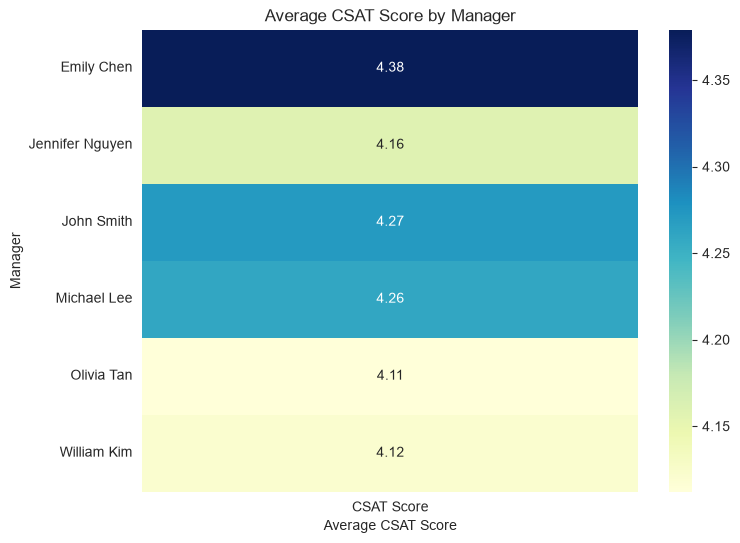

In [ ]:
manager_csat = df.groupby("Manager")["CSAT Score"].mean().to_frame()

plt.figure(figsize=(8,6))

sns.heatmap(
    manager_csat,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average CSAT Score by Manager")
plt.xlabel("Average CSAT Score")
plt.ylabel("Manager")

plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is used to compare the average CSAT scores of different managers and quickly identify performance differences.

##### 2. What is/are the insight(s) found from the chart?

- Emily Chen has the highest average CSAT score (4.38).
- Olivia Tan has the lowest average CSAT score (4.11).
- Most managers have average CSAT scores between 4.1 and 4.4, showing generally good performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps identify high-performing managers whose practices can be shared across teams. Managers with comparatively lower CSAT scores may require additional coaching or process improvements to enhance customer satisfaction.

#### Chart - 12  Number of Agents by Shift.

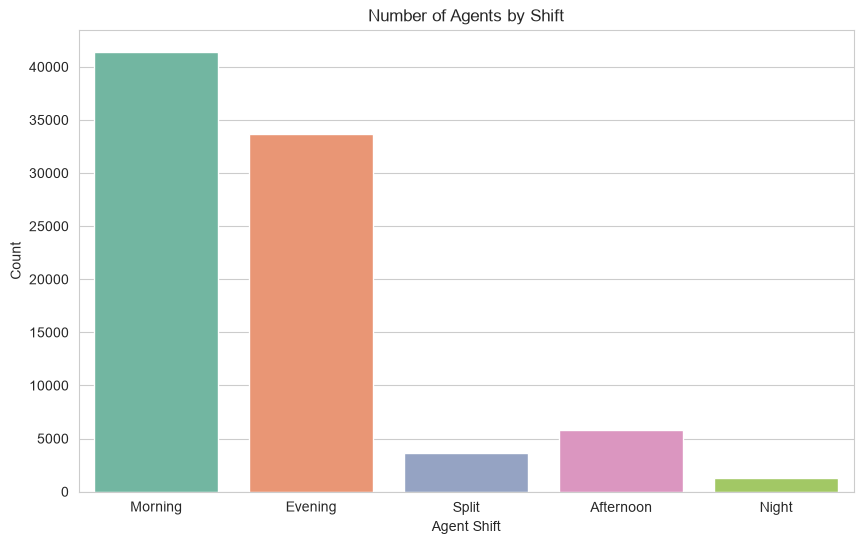

In [65]:
# Chart 12: Number of Agents by Shift

plt.figure(figsize=(10,6))

sns.countplot(
    x="Agent Shift",
    data=df,
    palette="Set2"
)

plt.title("Number of Agents by Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A count plot compares the number of agents across different shifts.

##### 2. What is/are the insight(s) found from the chart?

Morning and Evening shifts have the highest number of agents, while Night has the fewest.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

Proper staffing across shifts can improve service efficiency and customer satisfaction.

#### Chart - 13

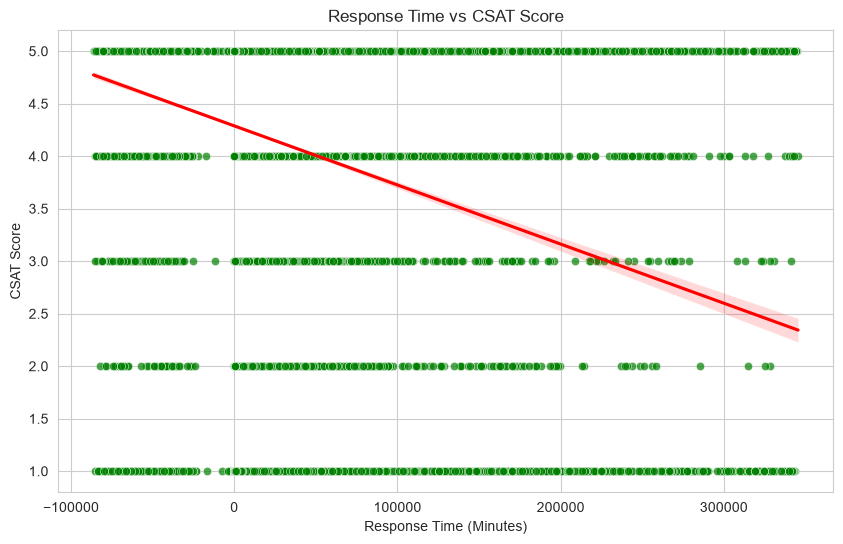

In [69]:
# Chart 13: Response Time vs CSAT Score with Regression Line

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="response_time",
    y="CSAT Score",
    data=df,
    alpha=0.7,
    color="green"
)

sns.regplot(
    x="response_time",
    y="CSAT Score",
    data=df,
    scatter=False,
    color="red"
)

plt.title("Response Time vs CSAT Score")
plt.xlabel("Response Time (Minutes)")
plt.ylabel("CSAT Score")

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a regression line helps visualize the relationship between response time and CSAT score.

##### 2. What is/are the insight(s) found from the chart?

The regression line shows a slight negative relationship, indicating that higher response times tend to be associated with lower CSAT scores.

##### 3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

Reducing response time can help improve customer satisfaction and enhance the overall support experience.

#### Chart - 14 - Correlation Heatmap

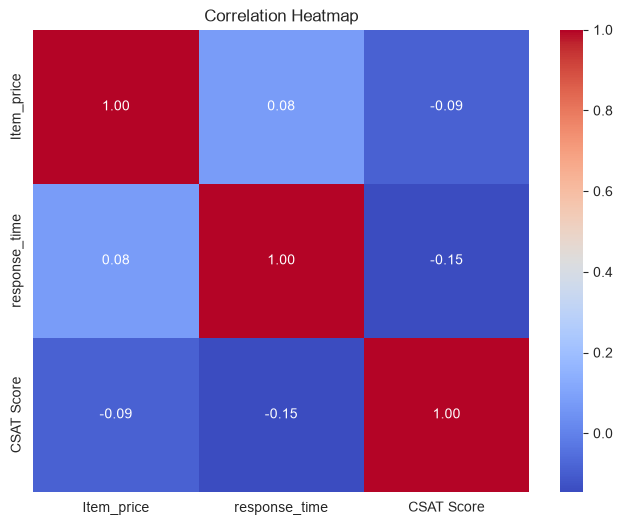

In [70]:
plt.figure(figsize=(8,6))

corr = df[["Item_price", "response_time", "CSAT Score"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap shows the strength and direction of relationships between numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Response time has a weak negative correlation with CSAT Score (-0.15), while Item Price has almost no correlation with CSAT Score (-0.09).

#### Chart - 15 - Pair Plot

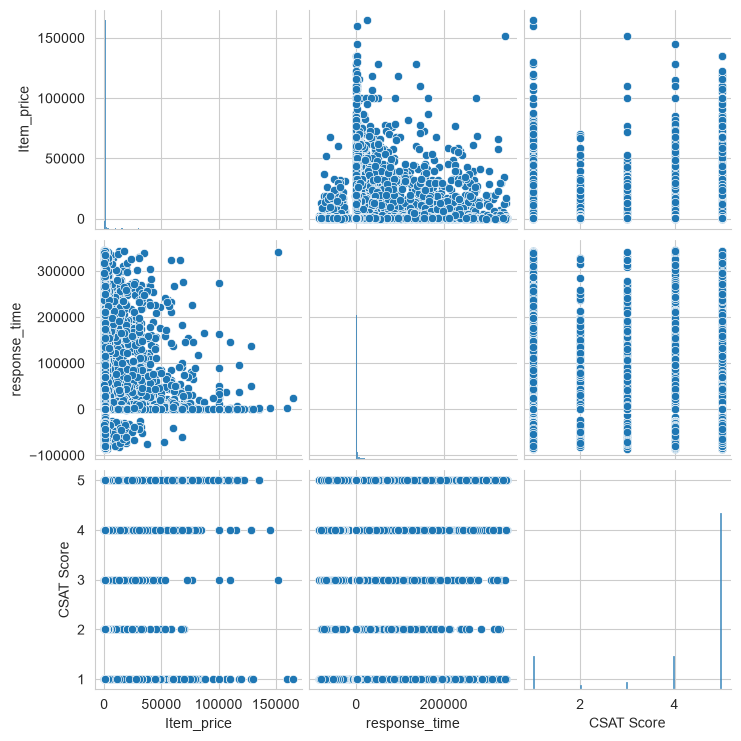

In [71]:
# Chart 15: Pair Plot

sns.pairplot(
    df[["Item_price", "response_time", "CSAT Score"]],
    diag_kind="hist"
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot helps visualize the relationships and distributions among multiple numerical variables at the same time.

##### 2. What is/are the insight(s) found from the chart?

Most data points are concentrated at lower item prices and higher CSAT scores (4–5). The variables show weak relationships, with no strong linear correlation.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

- Reduce customer response time to improve customer satisfaction.
- Provide additional training to new agents and lower-performing teams.
- Strengthen the Inbound support channel since it handles most customer interactions.
- Regularly monitor CSAT scores to identify service issues and improve support quality.
- Use predictive models to identify dissatisfied customers and take proactive actions.

# **Conclusion**

This project analyzed Flipkart customer service data to identify the factors affecting customer satisfaction (CSAT). Through data cleaning, feature engineering, visualization, and machine learning, key insights were obtained regarding response time, support channels, agent shifts, tenure, and product categories. The analysis showed that reducing response time and improving agent performance can enhance customer satisfaction. The Random Forest model achieved an accuracy of approximately 65%, demonstrating its potential for predicting customer satisfaction. These insights can help Flipkart improve service quality, optimize support operations, and deliver a better customer experience.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***